In [8]:
import pandas as pd

path = "../../data/raw/kathmandu_full_raw_2023_2024.csv"

data = pd.read_csv(path)

In [9]:
data["time"] = pd.to_datetime(data["time"])
data = data.sort_values("time")

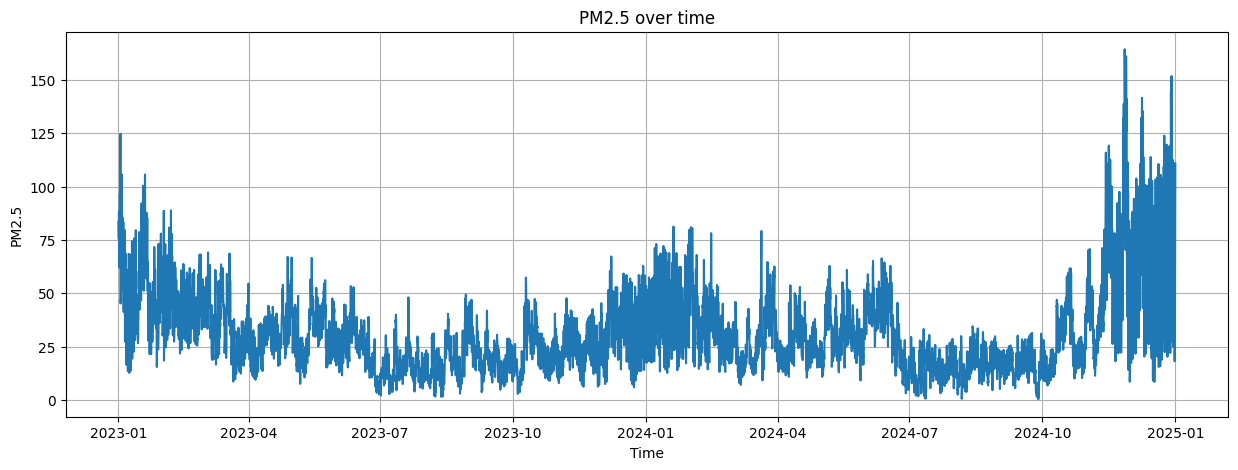

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(data["time"], data["pm2_5"])
plt.title("PM2.5 over time")
plt.xlabel("Time")
plt.ylabel("PM2.5")
plt.grid(True)
plt.show()

We can see that data around similar season have similar pattern.  
We will create new features based on the time and analyze. 

In [12]:
data["hour"] = data["time"].dt.hour
data["day_of_week"] = data["time"].dt.dayofweek
data["month"] = data["time"].dt.month

In [13]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Monsoon"
    else:
        return "Autumn"

data["season"] = data["time"].dt.month.apply(get_season)

In [ ]:
data.groupby("season")["pm2_5"].agg(["mean", "std", "max"]).sort_values(by="mean")

,mean,std,max
season,,,
Monsoon,20.603918,11.967050,66.4
Autumn,27.638645,20.831172,164.4
Spring,30.067980,11.750498,79.2
Winter,44.541575,22.230878,151.8


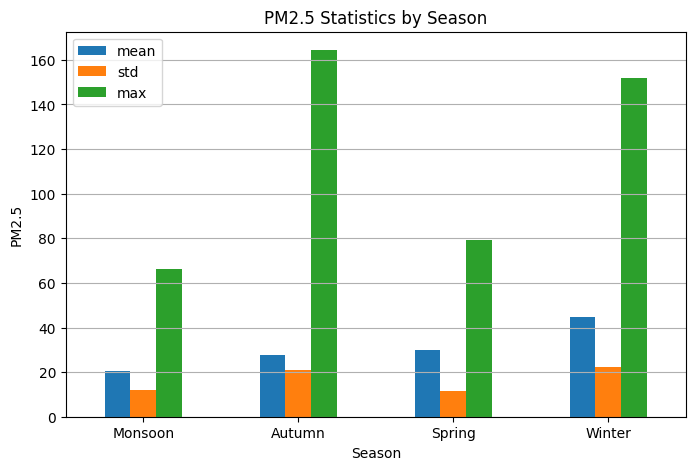

In [25]:
stats = data.groupby("season")["pm2_5"].agg(["mean", "std", "max"]).sort_values(by="mean")

stats.plot(kind="bar", figsize=(8,5))

plt.title("PM2.5 Statistics by Season")
plt.xlabel("Season")
plt.ylabel("PM2.5")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()